### HuyIGW04 - Softmax Regression - OOP 

In [30]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [31]:
data = np.genfromtxt('iris_2D_3c.csv', delimiter=',', skip_header=True)
X = torch.from_numpy(data[:, :-1]).float().to('cuda')
y = torch.from_numpy(data[:, -1]).long().to('cuda')
print(X.shape, y.shape)

torch.Size([9, 2]) torch.Size([9])


In [ ]:
input_dim = X.shape[1]
output_dim = len(y.unique())


class SoftmaxRegression(nn.Module):
    def __init__(self, input_f, output_f):
        # kế thừa lớp cha
        super().__init__()
        self.linear = nn.Linear(in_features=input_f, \
                                out_features=output_f).to('cuda')
    
    # forward function for OOP
    def forward(self, x):
        return self.linear(x)


# constructor
epochs = 1000
losses = []

model = SoftmaxRegression(input_dim, output_dim)
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# training
for epoch in range(epochs):
    y_hat = model(X)
    loss_epoch = loss(y_hat, y)
    losses.append(loss_epoch.item())

    optimizer.zero_grad()
    loss_epoch.backward()
    optimizer.step()

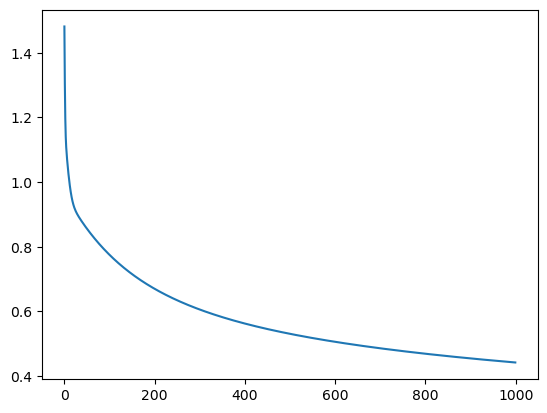

In [33]:
plt.plot(losses)